# 04. PyTorch 본학습 - ImageNet 사전학습 가중치 적용 (2차 재현 실험(직능원 교실 PC))

이 노트북은 기존 구조와 학습 조건을 유지하면서,
세 모델 각각에 대해 **Best Validation Loss 모델**과
**Best Validation Accuracy 모델**을 따로 저장하는 2차 재현 실험(직능원 교실 PC)용이다.

본학습 모델:
- MobileNetV3 Small
- EfficientNetB0
- ResNet18

공통 조건:
- Pretrained Weights: ImageNet DEFAULT
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- 최대 Epoch: 30
- EarlyStopping patience: 5
- EarlyStopping 기준: Validation Loss
- Scheduler / Weight Decay / Mixed Precision: 사용하지 않음
- `num_workers=0`

2차 재현 실험(직능원 교실 PC) 변경점:
- Validation Loss 최저 모델 별도 저장
- Validation Accuracy 최고 모델 별도 저장
- 기존 1차 실험 파일을 덮어쓰지 않도록 모든 새 파일명에 `v2_dual_best` 사용

> 전처리된 grayscale PNG, 데이터 연결 방식, 모델 구조, Optimizer,
> Learning Rate, Batch Size, EarlyStopping 조건은 1차 실험과 동일하게 유지한다.

## 실행 목적
이 노트북은 **집 PC에서 수행한 pretrained 2차 학습 코드를 그대로 다시 실행**하여,
직능원 교실의 **교실 PC(RTX 4060)**에서도 동일한 학습 조건에서 비슷한 성능 경향이 재현되는지 확인하기 위한 실험이다.

- 모델: MobileNetV3 Small / EfficientNetB0 / ResNet18
- 데이터, 전처리, 모델 구조, optimizer, batch size, epoch, EarlyStopping, learning rate 등 **학습 조건은 집 PC에서 수행한 2차 학습과 동일하게 유지한다.**
- 이 노트북은 **3차 추가 fine-tuning용 코드가 아니다.**
- 집 PC 결과를 덮어쓰지 않도록 모델과 `06_outputs` 저장 파일명에 `v2_repro_institute_seatpc` 태그를 사용한다.


## 1. 학습 환경 및 데이터 연결

- 1-1. 라이브러리 / GPU 확인
- 1-2. 프로젝트 경로 / 클래스 설정
- 1-3. grayscale PNG와 JSON 라벨 연결
- 1-4. 학습 직전 데이터 수 검증

여기서는 새로운 전처리를 하지 않고,
이미 만들어 둔 grayscale PNG와 `filename`, `faceExp_uploader`만 학습용으로 연결한다.

### 1-1. 라이브러리 / 랜덤 시드 / GPU 확인

필요한 라이브러리를 불러오고,
실행마다 결과 차이를 줄이기 위해 Python, NumPy, PyTorch의 랜덤 시드를 `42`로 고정한다.

그다음 현재 학습을 실행하는 집 PC에서
PyTorch가 CUDA와 RTX 4060 GPU를 정상 인식하는지 확인한다.

> 랜덤 시드를 고정해도 GPU 종류나 CUDA 연산 차이 때문에
> 집 PC와 직능원 PC 결과가 완전히 동일해지는 것은 아니다.
> 다만 모델 비교의 재현성과 비교 가능성을 높일 수 있다.

In [1]:
from pathlib import Path
import random
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# --------------------------------------------------
# 재현성을 높이기 위한 랜덤 시드 고정
# --------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed:", SEED)

# Windows에서 한글 그래프 라벨 표시
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# PyTorch / CUDA 확인
print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
print("GPU 개수:", torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Random Seed: 42
PyTorch: 2.5.1+cu121
CUDA 사용 가능: True
GPU 개수: 1
사용 장치: cuda
GPU: NVIDIA GeForce RTX 4060


### 1-2. 프로젝트 경로 및 감정 클래스 설정

기존 프로젝트 폴더의 이미지 / 라벨 / 모델 / 결과 경로를 지정하고,
7개 감정 클래스 순서를 정의한다.

In [2]:
# 프로젝트 기본 경로
PROJECT_ROOT = Path(r"D:\emotion_recognition_project")

# 기존 전처리된 grayscale PNG 경로
GRAY_TRAIN_DIR = (
    PROJECT_ROOT / "02_data" / "processed" / "grayscale_png" / "train"
)
GRAY_VALID_DIR = (
    PROJECT_ROOT / "02_data" / "processed" / "grayscale_png" / "valid"
)

# AI-Hub JSON 라벨 경로
TRAIN_LABEL_DIR = PROJECT_ROOT / "02_data" / "labels" / "train"
VALID_LABEL_DIR = PROJECT_ROOT / "02_data" / "labels" / "valid"

# 모델 / 결과 저장 경로
MODEL_DIR = PROJECT_ROOT / "05_models"
OUTPUT_DIR = PROJECT_ROOT / "06_outputs"

# 2차 실험 전용 태그: 1차 실험 파일 덮어쓰기 방지
EXPERIMENT_TAG = "v2_repro_institute_seatpc"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 7개 감정 클래스
CLASS_NAMES = ["기쁨", "당황", "분노", "불안", "상처", "슬픔", "중립"]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(CLASS_NAMES)}

print("모델 저장 경로:", MODEL_DIR)
print("결과 저장 경로:", OUTPUT_DIR)
print("2차 재현 실험(직능원 내 자리 PC) 태그:", EXPERIMENT_TAG)
print("감정 클래스:", CLASS_NAMES)


모델 저장 경로: D:\emotion_recognition_project\05_models
결과 저장 경로: D:\emotion_recognition_project\06_outputs
2차 재현 실험(직능원 내 자리 PC) 태그: v2_repro_institute_seatpc
감정 클래스: ['기쁨', '당황', '분노', '불안', '상처', '슬픔', '중립']


### 1-3. grayscale PNG와 JSON 라벨 연결

전처리된 PNG의 파일명과 AI-Hub JSON의 `filename`을 연결하고,
최종 학습 라벨은 `faceExp_uploader`를 사용한다.

In [3]:
def build_dataframe(image_dir, label_dir):
    # grayscale PNG 파일명을 기준으로 이미지 경로를 빠르게 찾기 위한 딕셔너리
    image_map = {
        path.stem: path
        for path in image_dir.glob("*.png")
    }

    records = []

    # 여러 JSON 파일을 순서대로 읽는다.
    for json_path in sorted(label_dir.rglob("*.json")):
        with open(json_path, "r", encoding="utf-8") as f:
            label_data = json.load(f)

        for record in label_data:
            original_name = record["filename"]
            stem = Path(original_name).stem
            label = record["faceExp_uploader"]

            # 실제 존재하는 grayscale PNG와 7개 감정 라벨만 연결
            if stem in image_map and label in LABEL_TO_IDX:
                records.append({
                    "filename": original_name,
                    "image_path": str(image_map[stem]),
                    "label": label,
                    "label_index": LABEL_TO_IDX[label],
                })

    return pd.DataFrame(records)


train_df = build_dataframe(GRAY_TRAIN_DIR, TRAIN_LABEL_DIR)
valid_df = build_dataframe(GRAY_VALID_DIR, VALID_LABEL_DIR)

print("Training 연결 수:", len(train_df))
print("Validation 연결 수:", len(valid_df))


Training 연결 수: 223578
Validation 연결 수: 52126


### 1-4. 학습 직전 데이터 수 및 샘플 확인

Training 223,578건과 Validation 52,126건이 정확히 연결됐는지 마지막으로 확인하고,
샘플 filename / label / label_index를 확인한다.

In [4]:
# 학습 직전 마지막 안전 검증
assert len(train_df) == 223578, f"Training 수가 예상과 다릅니다: {len(train_df)}"
assert len(valid_df) == 52126, f"Validation 수가 예상과 다릅니다: {len(valid_df)}"

# filename / label / label_index 샘플 확인
display(train_df[["filename", "label", "label_index"]].head(5))
display(valid_df[["filename", "label", "label_index"]].head(5))


,filename,label,label_index
0,5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf5...,기쁨,0
1,92e7098109470430238876b447f55a978adf237c93b438...,기쁨,0
2,5a30dc193e2c6144184968043c00773270b111a23a3c83...,기쁨,0
3,29b5343b8eca7460aea95cd18db40b015a58ec4db64b71...,기쁨,0
4,4e91bb1317ff7616b99cadf3cafaf8dab49bc6985a0367...,기쁨,0


,filename,label,label_index
0,dd99b4f896bcc238d52bc84321602614d8897215bde8cd...,기쁨,0
1,9e7bac24f25feb3db4a759b4c2b409f28f7ff3f669713c...,기쁨,0
2,d457724868d30d15df5f1d6b67c262d87a064c1f9309aa...,기쁨,0
3,21ee461934c5f88f24993d031484c617fb911a03ead847...,기쁨,0
4,1c4190dff43fb38b2f88320665a6d094ce633815248c7c...,기쁨,0


## 2. Dataset / DataLoader 구성

`Dataset`은 이미지와 라벨을 한 장씩 불러오는 역할을 하고,
`DataLoader`는 전체 데이터를 `batch_size=32` 단위로 모델에 공급한다.

원본 grayscale PNG는 1채널이지만,
MobileNetV3 Small / EfficientNetB0 / ResNet18의 기본 입력 구조에 맞추기 위해
**동일한 흑백 값을 3채널로 복제**한다.

In [5]:
# --------------------------------------------------
# 모델 입력용 transform
# --------------------------------------------------
# Grayscale(num_output_channels=3)은 흑백 값을 R/G/B 3채널에 동일하게 복제한다.
# 새로운 색 정보를 만드는 것이 아니므로 컬러 복원이 아니다.
# 이후 ImageNet 사전학습 가중치에 맞는 mean/std 정규화를 적용한다.
image_transform = transforms.Compose([
    # grayscale 값을 3채널에 동일하게 복제
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),

    # ImageNet 사전학습 가중치에 맞춘 정규화
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # 이미 전처리된 224x224 grayscale PNG를 그대로 읽는다.
        image = Image.open(row["image_path"]).convert("L")
        label = int(row["label_index"])

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = EmotionDataset(train_df, transform=image_transform)
valid_dataset = EmotionDataset(valid_df, transform=image_transform)

# 학습 직전 Dataset 길이 확인
assert len(train_dataset) == 223578
assert len(valid_dataset) == 52126

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

print("train_dataset:", len(train_dataset))
print("valid_dataset:", len(valid_dataset))
print("Training batch 수:", len(train_loader))
print("Validation batch 수:", len(valid_loader))

# 실제 입력 모양 확인
sample_images, sample_labels = next(iter(train_loader))
print("이미지 batch shape:", sample_images.shape)   # [32, 3, 224, 224]
print("라벨 batch shape:", sample_labels.shape)
print("샘플 라벨 index:", sample_labels[:5].tolist())


train_dataset: 223578
valid_dataset: 52126
Training batch 수: 6987
Validation batch 수: 1629
이미지 batch shape: torch.Size([32, 3, 224, 224])
라벨 batch shape: torch.Size([32])
샘플 라벨 index: [2, 0, 6, 4, 2]


## 3. 모델 구성 및 공통 학습·평가 함수

- 3-1. 모델 생성
- 3-2. 학습 Loss / Accuracy 그래프
- 3-3. Precision / Recall / F1 / Confusion Matrix 그래프
- 3-4. Best model 최종 평가
- 3-5. 본학습 함수

### 3-1. 모델 생성

MobileNetV3 Small, EfficientNetB0, ResNet18 중 선택한 모델을 만들고,
마지막 분류층을 7개 감정 클래스에 맞게 변경한다.

세 모델 모두 torchvision에서 제공하는 **ImageNet DEFAULT 사전학습 가중치**를 사용한다.

사전학습된 기본 시각 특징을 활용하되,
마지막 분류층은 7개 감정 분류에 맞게 새로 구성하고
전체 모델을 Fine-tuning한다.

In [6]:
def create_model(model_name, num_classes=7):
    if model_name == "mobilenet_v3_small":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "resnet18":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"지원하지 않는 모델명입니다: {model_name}")

    return model


# 모델 구조와 사전학습 가중치 로딩이 정상인지 확인
# 처음 실행할 때는 torchvision이 가중치 파일을 다운로드할 수 있다.
for name in ["mobilenet_v3_small", "efficientnet_b0", "resnet18"]:
    test_model = create_model(name)
    print(name, "사전학습 가중치 적용 완료")

del test_model


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 90.0MB/s]
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


mobilenet_v3_small 사전학습 가중치 적용 완료


100%|██████████| 20.5M/20.5M [00:00<00:00, 101MB/s]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


efficientnet_b0 사전학습 가중치 적용 완료


100%|██████████| 44.7M/44.7M [00:00<00:00, 106MB/s] 

resnet18 사전학습 가중치 적용 완료


### 3-2. 학습 과정 그래프 함수

매 Epoch마다 저장된 history를 이용해
**Train / Validation Loss**와 **Train / Validation Accuracy** 그래프를 만든다.

그래프는 Matplotlib으로 출력하고 `06_outputs/`에도 PNG로 저장한다.

In [7]:
def save_history_graphs(history_df, model_name):
    # ------------------------------
    # 1) Loss 그래프
    # ------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_pretrained_{EXPERIMENT_TAG}_loss_curve.png", dpi=150)
    plt.show()
    plt.close()

    # ------------------------------
    # 2) Accuracy 그래프
    # ------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["valid_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_pretrained_{EXPERIMENT_TAG}_accuracy_curve.png", dpi=150)
    plt.show()
    plt.close()

### 3-3. Validation 평가지표 그래프 함수

Best model 평가 결과를 시각화한다.

- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

모두 Matplotlib으로 생성하고 `06_outputs/`에 저장한다.

In [8]:
def save_class_metric_graph(values, metric_name, model_name, checkpoint_type):
    plt.figure(figsize=(9, 5))
    plt.bar(CLASS_NAMES, values)
    plt.ylim(0, 1)
    plt.xlabel("감정 클래스")
    plt.ylabel(metric_name)
    plt.title(f"{model_name} - {checkpoint_type} - {metric_name} by Class")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_{checkpoint_type}_{metric_name.lower()}_by_class.png",
        dpi=150,
    )
    plt.show()
    plt.close()


def save_confusion_matrix_graph(cm, model_name, checkpoint_type):
    plt.figure(figsize=(8, 7))
    plt.imshow(cm)
    plt.title(f"{model_name} - {checkpoint_type} - Confusion Matrix")
    plt.xlabel("예측 라벨")
    plt.ylabel("실제 라벨")
    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_{checkpoint_type}_confusion_matrix.png",
        dpi=150,
    )
    plt.show()
    plt.close()

### 3-4. Best model Validation 평가

EarlyStopping과 Best model 선택에 사용한 **같은 Validation set**을 이용해
선택된 Best model의 성능을 다시 정리한다.

확인하는 지표:
- Accuracy
- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

> 현재 프로젝트에서는 별도의 Test set을 추가하지 않고,
> **Best model의 Validation 평가 결과**로 성능을 정리한다.

#### 3-4-1. Best model 불러오기 및 예측값 수집

저장된 Best model의 가중치를 불러온 뒤,
Validation 전체 데이터에 대해 실제 라벨(`y_true`)과 예측 라벨(`y_pred`)을 모은다.

In [9]:
def collect_predictions(model_name, valid_loader, device, best_model_path):
    # 모델 구조를 다시 만들고 Best model 가중치를 불러온다.
    model = create_model(model_name).to(device)
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    y_true = []
    y_pred = []

    # 평가 단계에서는 gradient 계산이 필요 없다.
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            # 최종 평가를 위해 CPU의 리스트에 정답과 예측값을 모은다.
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


#### 3-4-2. 평가지표 계산

수집한 `y_true`, `y_pred`를 이용해 다음 지표를 계산한다.

- Accuracy
- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

평가지표 계산과 파일/그래프 저장을 분리해서 보기 쉽게 구성한다.

In [10]:
def calculate_metrics(y_true, y_pred):
    # 전체 Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # 7개 감정별 Precision / Recall / F1
    precision = precision_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    recall = recall_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    f1 = f1_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=range(len(CLASS_NAMES)),
    )

    return accuracy, precision, recall, f1, cm


#### 3-4-3. 클래스별 평가표 및 그래프 저장

계산된 Precision / Recall / F1을 감정별 표로 만들고 CSV로 저장한다.

그다음 각 지표와 Confusion Matrix를 Matplotlib 그래프로 저장한다.

In [11]:
def save_evaluation_results(
    model_name,
    checkpoint_type,
    accuracy,
    precision,
    recall,
    f1,
    cm,
):
    class_metrics_df = pd.DataFrame({
        "class": CLASS_NAMES,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    })

    class_metrics_df.to_csv(
        OUTPUT_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_{checkpoint_type}_class_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )

    print(f"\n[{model_name}] {checkpoint_type} Validation 평가")
    print("Accuracy:", round(accuracy, 4))
    display(class_metrics_df)

    save_class_metric_graph(precision, "Precision", model_name, checkpoint_type)
    save_class_metric_graph(recall, "Recall", model_name, checkpoint_type)
    save_class_metric_graph(f1, "F1", model_name, checkpoint_type)
    save_confusion_matrix_graph(cm, model_name, checkpoint_type)

    return class_metrics_df

#### 3-4-4. Best model Validation 평가 실행 함수

앞에서 만든 기능을 순서대로 연결한다.

1. Best model 예측값 수집
2. Accuracy / Precision / Recall / F1 / Confusion Matrix 계산
3. CSV와 그래프 저장
4. 세 모델 비교용 대표값 반환

In [12]:
def evaluate_best_model(
    model_name,
    valid_loader,
    device,
    best_model_path,
    checkpoint_type,
):
    y_true, y_pred = collect_predictions(
        model_name=model_name,
        valid_loader=valid_loader,
        device=device,
        best_model_path=best_model_path,
    )

    accuracy, precision, recall, f1, cm = calculate_metrics(
        y_true,
        y_pred,
    )

    save_evaluation_results(
        model_name=model_name,
        checkpoint_type=checkpoint_type,
        accuracy=accuracy,
        precision=precision,
        recall=recall,
        f1=f1,
        cm=cm,
    )

    return {
        "model": model_name,
        "checkpoint_type": checkpoint_type,
        "accuracy": accuracy,
        "mean_precision": precision.mean(),
        "mean_recall": recall.mean(),
        "mean_f1": f1.mean(),
    }

### 3-5. 본학습 함수

본학습에서 반복해서 사용할 Training 함수와 Validation 함수를 먼저 정의하고,
그다음 최대 30 Epoch까지 학습을 반복하는 본학습 함수를 정의한다.

#### 3-5-1. Training / Validation 처리 함수

본학습에서 매 Epoch마다 사용할 두 함수를 `def`로 미리 정의한다.

- `train_one_epoch()` : Training 데이터를 학습하고 가중치를 업데이트
- `validate_one_epoch()` : Validation 데이터로 성능만 확인하고 가중치는 업데이트하지 않음

이 두 함수는 다음 단계의 `train_model()`에서 반복해서 호출한다.

In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 이전 batch의 gradient 초기화
        optimizer.zero_grad()

        # 예측 → 손실 계산 → 역전파 → 가중치 업데이트
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Epoch 평균 Loss와 Accuracy 계산용 누적
        loss_sum += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = loss_sum / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy



def validate_one_epoch(model, valid_loader, criterion, device):
    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = loss_sum / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


#### 3-5-2. 학습 준비

1차 실험과 같은 모델 / 손실함수 / Optimizer를 사용한다.

2차 재현 실험(직능원 교실 PC)에서는 저장 경로만 확장한다.

- Best Validation Loss model
- Best Validation Accuracy model
- Epoch history

모든 파일명에는 `v2_dual_best`가 포함되어 기존 결과를 덮어쓰지 않는다.

In [14]:
def prepare_training(model_name, device, learning_rate):
    model = create_model(model_name).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    best_loss_model_path = (
        MODEL_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_best_loss.pt"
    )

    best_accuracy_model_path = (
        MODEL_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_best_accuracy.pt"
    )

    history_path = (
        OUTPUT_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_history.csv"
    )

    return (
        model,
        criterion,
        optimizer,
        best_loss_model_path,
        best_accuracy_model_path,
        history_path,
    )

#### 3-5-3. Epoch 결과 기록 함수

한 Epoch이 끝날 때마다 Train/Validation Loss와 Accuracy를 `history`에 추가하고,
CSV 파일로 저장한다.

학습 중간에 종료되더라도 완료된 Epoch 기록이 남도록 하는 역할이다.

In [15]:
def save_epoch_result(
    history,
    history_path,
    epoch,
    train_loss,
    train_acc,
    valid_loss,
    valid_acc,
    epoch_seconds,
):
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "valid_loss": valid_loss,
        "valid_accuracy": valid_acc,
        "epoch_seconds": epoch_seconds,
    })

    pd.DataFrame(history).to_csv(
        history_path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"valid_loss={valid_loss:.4f} | "
        f"valid_acc={valid_acc:.4f} | "
        f"{epoch_seconds:.1f}s"
    )


#### 3-5-4. Best model 저장 및 EarlyStopping 확인 함수

2차 재현 실험(직능원 내 자리 PC)에서는 두 종류의 Best 모델을 따로 저장한다.

- Validation Loss가 가장 낮으면 `best_loss`
- Validation Accuracy가 가장 높으면 `best_accuracy`

EarlyStopping은 1차 실험과 동일하게 **Validation Loss 기준**으로 유지한다.
Validation Loss가 5 Epoch 연속 개선되지 않으면 학습을 종료한다.

In [16]:
def check_best_models_and_early_stopping(
    model,
    valid_loss,
    valid_acc,
    best_val_loss,
    best_val_acc,
    no_improve_count,
    patience,
    best_loss_model_path,
    best_accuracy_model_path,
):
    # 1) Validation Loss 기준 Best 모델 저장
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        no_improve_count = 0

        torch.save(model.state_dict(), best_loss_model_path)
        print("  -> Best Loss model 저장:", best_loss_model_path.name)

    else:
        no_improve_count += 1
        print(
            f"  -> Validation loss 개선 없음 "
            f"({no_improve_count}/{patience})"
        )

    # 2) Validation Accuracy 기준 Best 모델 별도 저장
    if valid_acc > best_val_acc:
        best_val_acc = valid_acc

        torch.save(model.state_dict(), best_accuracy_model_path)
        print(
            "  -> Best Accuracy model 저장:",
            best_accuracy_model_path.name,
        )

    # 3) EarlyStopping은 Validation Loss 기준
    should_stop = no_improve_count >= patience

    return (
        best_val_loss,
        best_val_acc,
        no_improve_count,
        should_stop,
    )

#### 3-5-5. 본학습 반복 함수

1차 실험의 학습 흐름을 유지한다.

매 Epoch마다:
1. Training
2. Validation
3. 결과 기록
4. Best Validation Loss 모델 저장
5. Best Validation Accuracy 모델 저장
6. Validation Loss 기준 EarlyStopping 확인

학습 종료 후 Loss / Accuracy 그래프를 저장한다.

In [17]:
def train_model(
    model_name,
    train_loader,
    valid_loader,
    device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
):
    (
        model,
        criterion,
        optimizer,
        best_loss_model_path,
        best_accuracy_model_path,
        history_path,
    ) = prepare_training(
        model_name,
        device,
        learning_rate,
    )

    history = []
    best_val_loss = float("inf")
    best_val_acc = -1.0
    no_improve_count = 0

    print(f"\n===== {model_name} 2차 학습 시작 =====")

    try:
        for epoch in range(1, max_epochs + 1):
            epoch_start = time.time()

            train_loss, train_acc = train_one_epoch(
                model, train_loader, criterion, optimizer, device
            )

            valid_loss, valid_acc = validate_one_epoch(
                model, valid_loader, criterion, device
            )

            epoch_seconds = time.time() - epoch_start

            save_epoch_result(
                history,
                history_path,
                epoch,
                train_loss,
                train_acc,
                valid_loss,
                valid_acc,
                epoch_seconds,
            )

            (
                best_val_loss,
                best_val_acc,
                no_improve_count,
                should_stop,
            ) = check_best_models_and_early_stopping(
                model=model,
                valid_loss=valid_loss,
                valid_acc=valid_acc,
                best_val_loss=best_val_loss,
                best_val_acc=best_val_acc,
                no_improve_count=no_improve_count,
                patience=patience,
                best_loss_model_path=best_loss_model_path,
                best_accuracy_model_path=best_accuracy_model_path,
            )

            if should_stop:
                print(f"  -> EarlyStopping: Epoch {epoch}에서 종료")
                break

    except KeyboardInterrupt:
        print(
            "\n사용자 중단 감지: 완료된 Epoch까지 history CSV와 "
            "이미 저장된 Best 모델은 유지됩니다."
        )

    history_df = pd.DataFrame(history)

    if not history_df.empty:
        save_history_graphs(history_df, model_name)

    print("Best Loss model 경로:", best_loss_model_path)
    print("Best Accuracy model 경로:", best_accuracy_model_path)
    print("History CSV 경로:", history_path)

    return (
        history_df,
        best_loss_model_path,
        best_accuracy_model_path,
    )

## 4. 모델별 본학습

세 모델은 1차 실험과 동일한 데이터와 학습 조건을 사용한다.

실행 순서:
1. MobileNetV3 Small
2. EfficientNetB0
3. ResNet18

각 모델 학습이 끝나면 다음 두 체크포인트를 각각 평가한다.

- Best Validation Loss model
- Best Validation Accuracy model

두 체크포인트 모두 같은 Validation set에서
Accuracy / Precision / Recall / F1-score / Confusion Matrix를 확인한다.

### 4-1. MobileNetV3 Small 본학습

가벼운 구조의 MobileNetV3 Small을 먼저 학습한다.


===== mobilenet_v3_small 2차 학습 시작 =====
Epoch 01 | train_loss=1.1587 | train_acc=0.5620 | valid_loss=1.0997 | valid_acc=0.5846 | 818.0s
  -> Best Loss model 저장: mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 02 | train_loss=0.9834 | train_acc=0.6312 | valid_loss=1.0597 | valid_acc=0.6141 | 647.1s
  -> Best Loss model 저장: mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 03 | train_loss=0.9049 | train_acc=0.6608 | valid_loss=1.0202 | valid_acc=0.6262 | 647.8s
  -> Best Loss model 저장: mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 04 | train_loss=0.8457 | train_acc=0.6828 | valid_loss=1.0068 | valid_acc=0.6

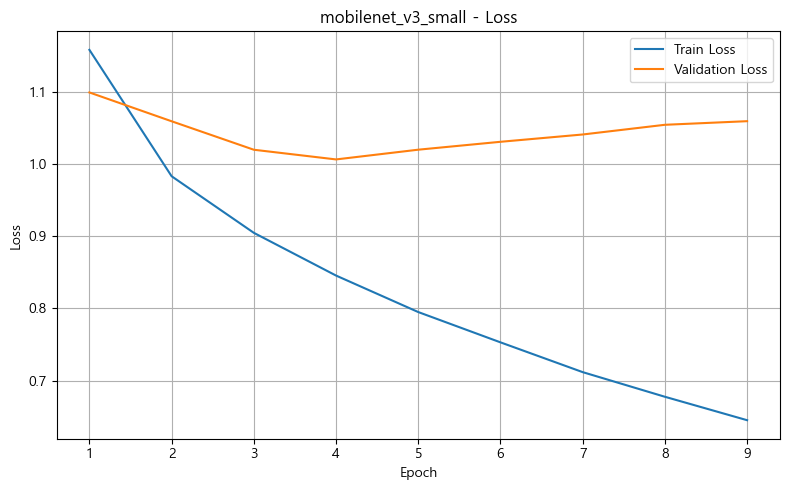

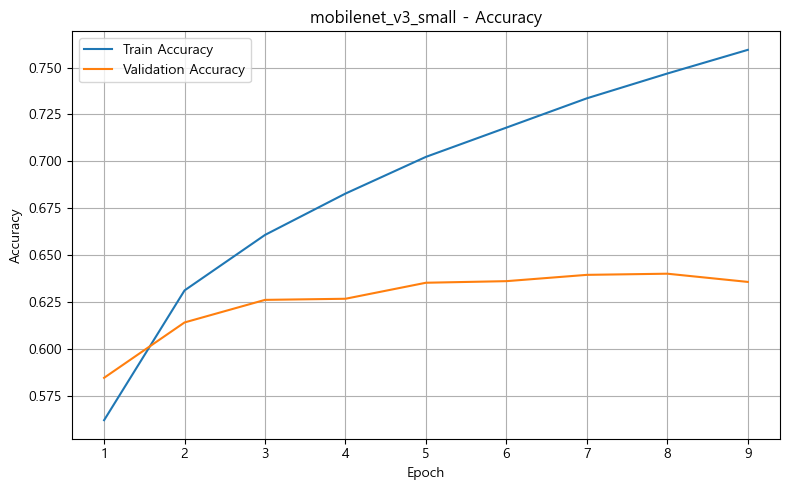

Best Loss model 경로: D:\emotion_recognition_project\05_models\mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_best_loss.pt
Best Accuracy model 경로: D:\emotion_recognition_project\05_models\mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\mobilenet_v3_small_pretrained_v2_repro_institute_seatpc_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_16156\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[mobilenet_v3_small] best_loss Validation 평가
Accuracy: 0.6268


,class,precision,recall,f1_score
0,기쁨,0.910841,0.920923,0.915854
1,당황,0.665041,0.713577,0.688455
2,분노,0.714565,0.588527,0.645451
3,불안,0.509413,0.306872,0.383015
4,상처,0.356341,0.457632,0.400684
5,슬픔,0.609597,0.613184,0.611385
6,중립,0.652820,0.783331,0.712145


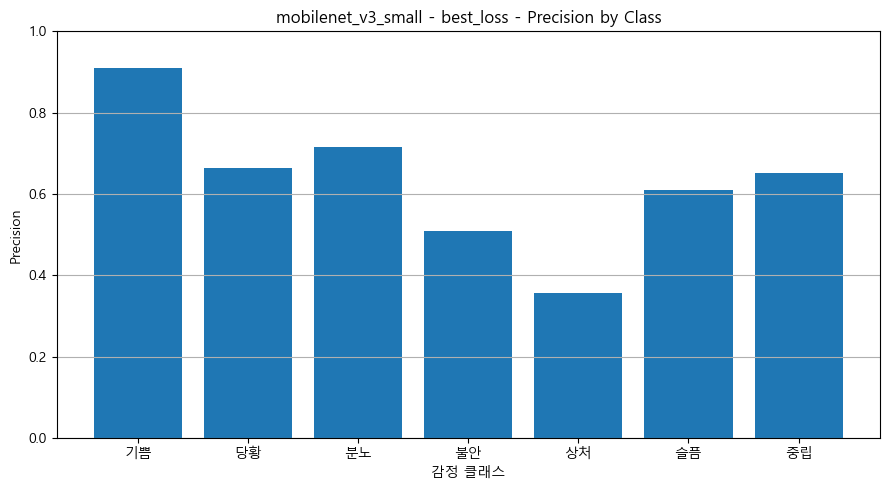

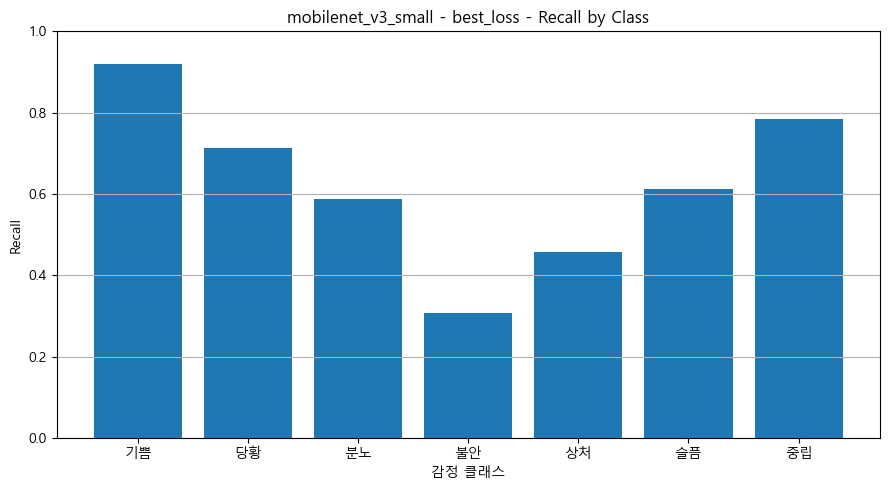

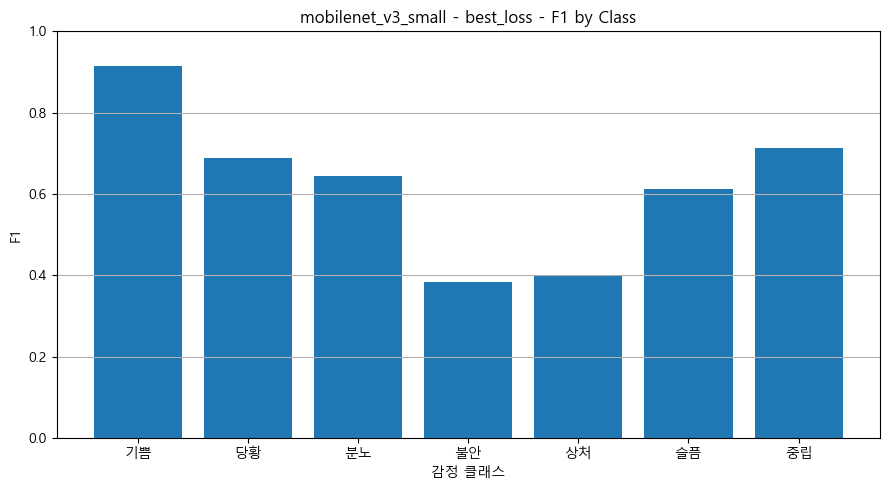

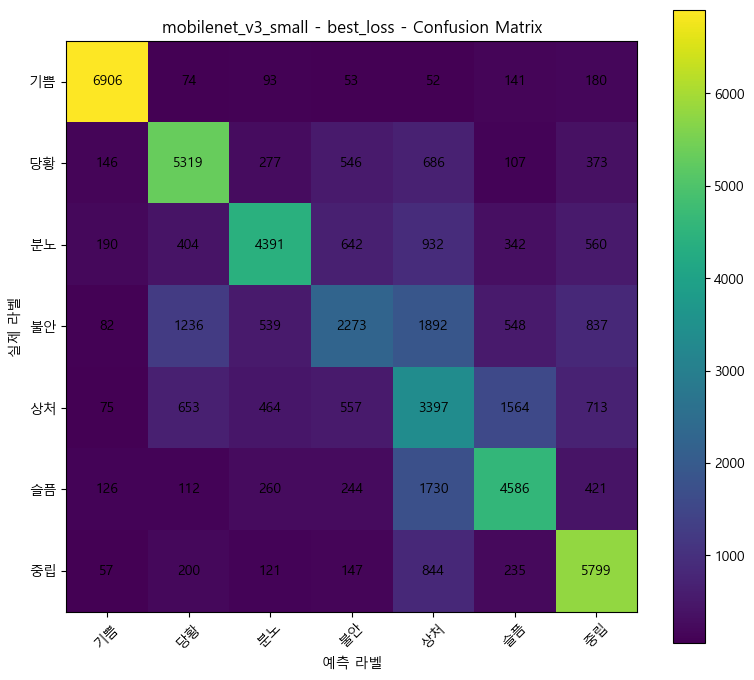

C:\Users\USER\AppData\Local\Temp\ipykernel_16156\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[mobilenet_v3_small] best_accuracy Validation 평가
Accuracy: 0.6401


,class,precision,recall,f1_score
0,기쁨,0.904115,0.922923,0.913422
1,당황,0.730012,0.656560,0.691341
2,분노,0.589757,0.739311,0.656120
3,불안,0.430855,0.509383,0.466840
4,상처,0.478563,0.315775,0.380489
5,슬픔,0.696933,0.534697,0.605130
6,중립,0.656247,0.799676,0.720896


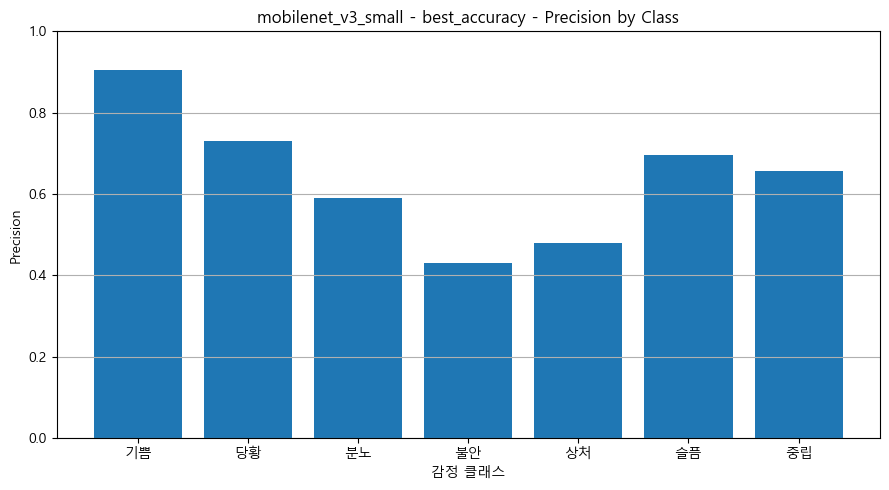

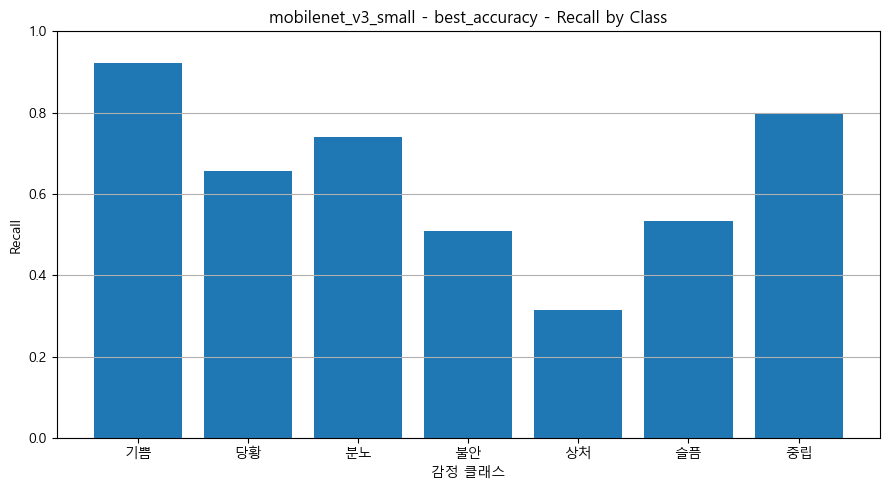

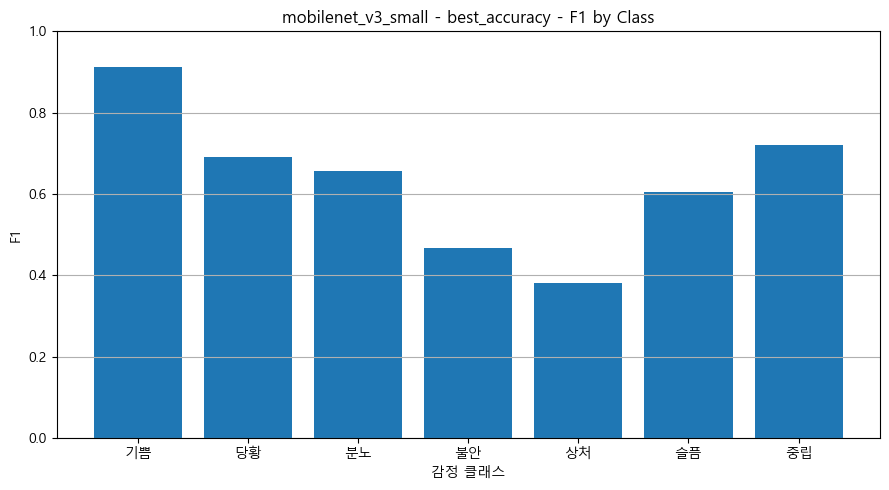

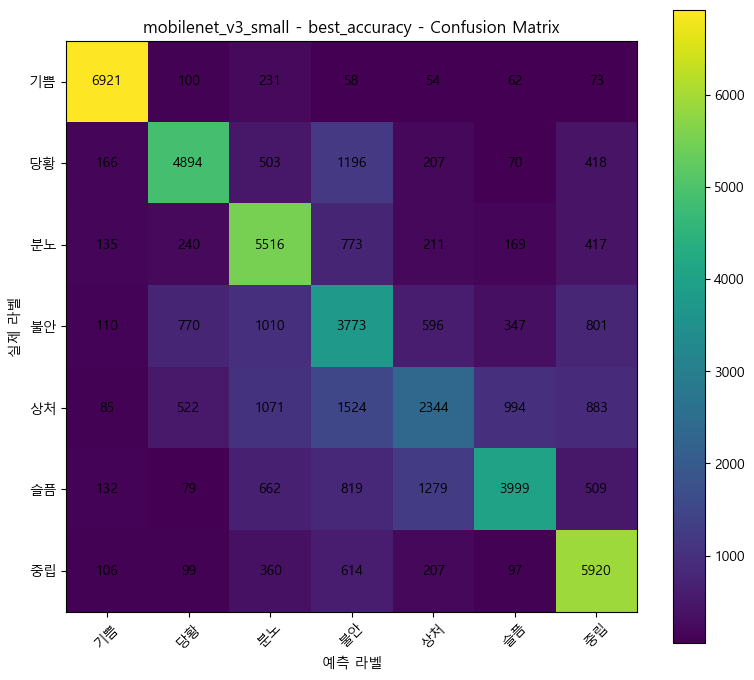

In [18]:
# 4-1. MobileNetV3 Small
mobilenet_history, mobilenet_best_loss_path, mobilenet_best_accuracy_path = train_model(
    model_name="mobilenet_v3_small",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

mobilenet_loss_result = evaluate_best_model(
    model_name="mobilenet_v3_small",
    valid_loader=valid_loader,
    device=device,
    best_model_path=mobilenet_best_loss_path,
    checkpoint_type="best_loss",
)

mobilenet_accuracy_result = evaluate_best_model(
    model_name="mobilenet_v3_small",
    valid_loader=valid_loader,
    device=device,
    best_model_path=mobilenet_best_accuracy_path,
    checkpoint_type="best_accuracy",
)


### 4-2. EfficientNetB0 본학습

같은 조건으로 EfficientNetB0을 학습한다.


===== efficientnet_b0 2차 학습 시작 =====
Epoch 01 | train_loss=1.0031 | train_acc=0.6257 | valid_loss=0.9912 | valid_acc=0.6300 | 1199.7s
  -> Best Loss model 저장: efficientnet_b0_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: efficientnet_b0_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 02 | train_loss=0.8222 | train_acc=0.6945 | valid_loss=0.9279 | valid_acc=0.6689 | 1202.3s
  -> Best Loss model 저장: efficientnet_b0_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: efficientnet_b0_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 03 | train_loss=0.7308 | train_acc=0.7298 | valid_loss=0.8757 | valid_acc=0.6855 | 1204.8s
  -> Best Loss model 저장: efficientnet_b0_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: efficientnet_b0_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 04 | train_loss=0.6607 | train_acc=0.7557 | valid_loss=0.8659 | valid_acc=0.6955 | 1201.9s
  ->

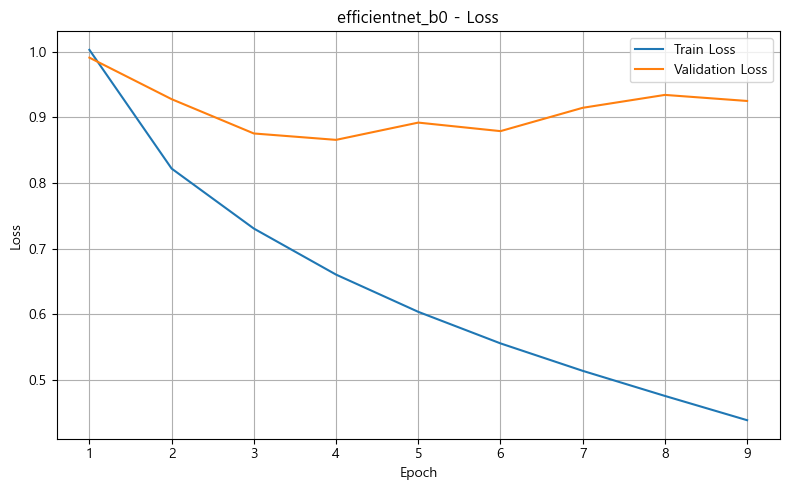

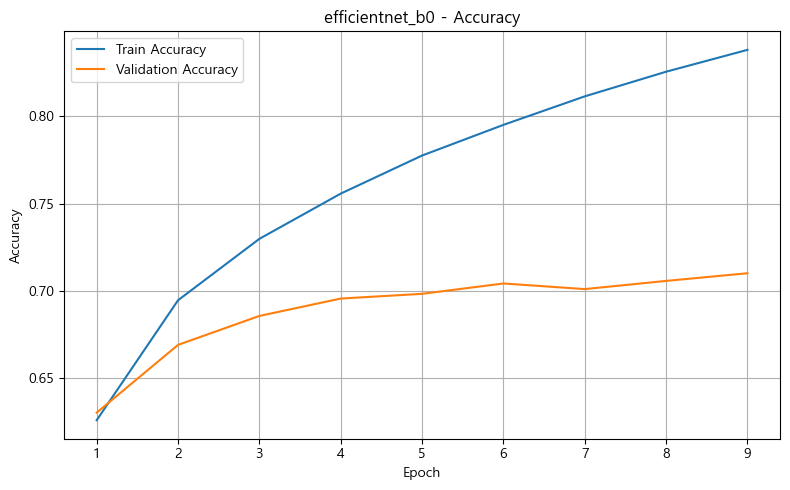

Best Loss model 경로: D:\emotion_recognition_project\05_models\efficientnet_b0_pretrained_v2_repro_institute_seatpc_best_loss.pt
Best Accuracy model 경로: D:\emotion_recognition_project\05_models\efficientnet_b0_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\efficientnet_b0_pretrained_v2_repro_institute_seatpc_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_16156\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[efficientnet_b0] best_loss Validation 평가
Accuracy: 0.6955


,class,precision,recall,f1_score
0,기쁨,0.940354,0.941859,0.941106
1,당황,0.761027,0.719882,0.739883
2,분노,0.759507,0.701381,0.729287
3,불안,0.536292,0.492777,0.513614
4,상처,0.455527,0.437424,0.446292
5,슬픔,0.629215,0.736061,0.678457
6,중립,0.774496,0.836012,0.804080


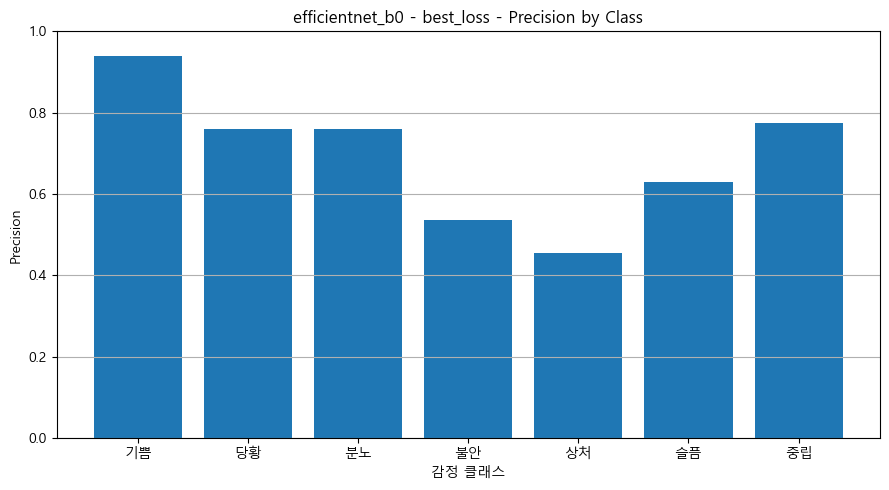

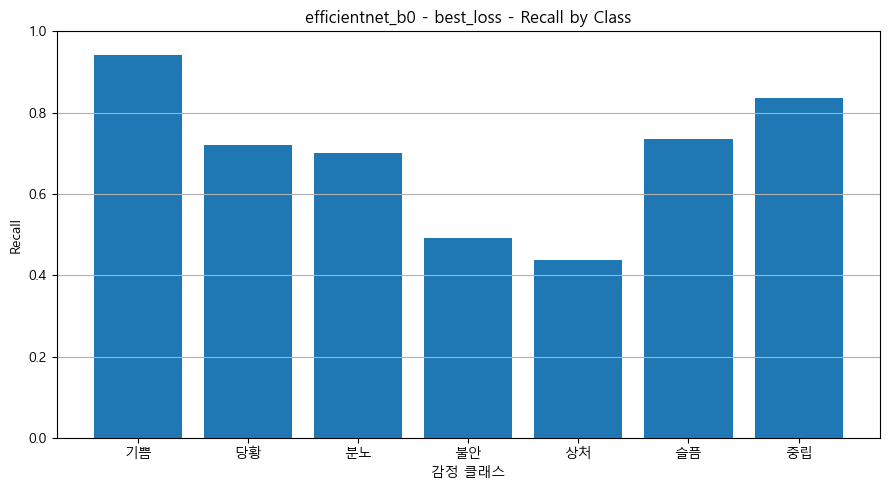

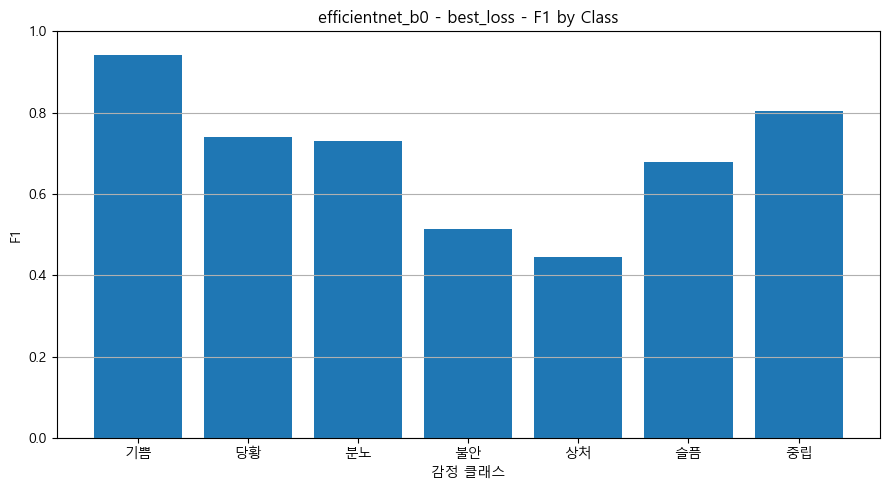

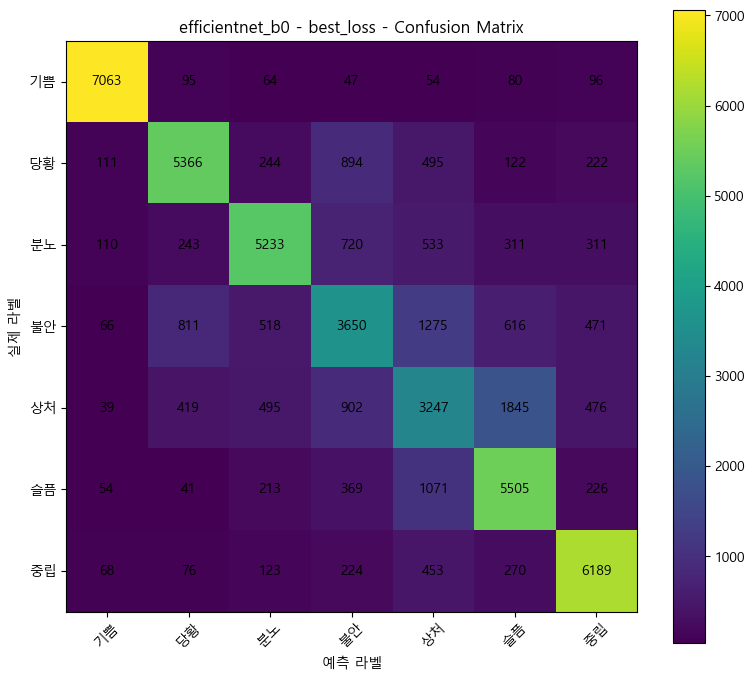

C:\Users\USER\AppData\Local\Temp\ipykernel_16156\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[efficientnet_b0] best_accuracy Validation 평가
Accuracy: 0.71


,class,precision,recall,f1_score
0,기쁨,0.938533,0.946793,0.942645
1,당황,0.718730,0.768581,0.742820
2,분노,0.767740,0.722155,0.744250
3,불안,0.544234,0.519914,0.531796
4,상처,0.493373,0.471373,0.482122
5,슬픔,0.692851,0.694612,0.693730
6,중립,0.790286,0.843982,0.816252


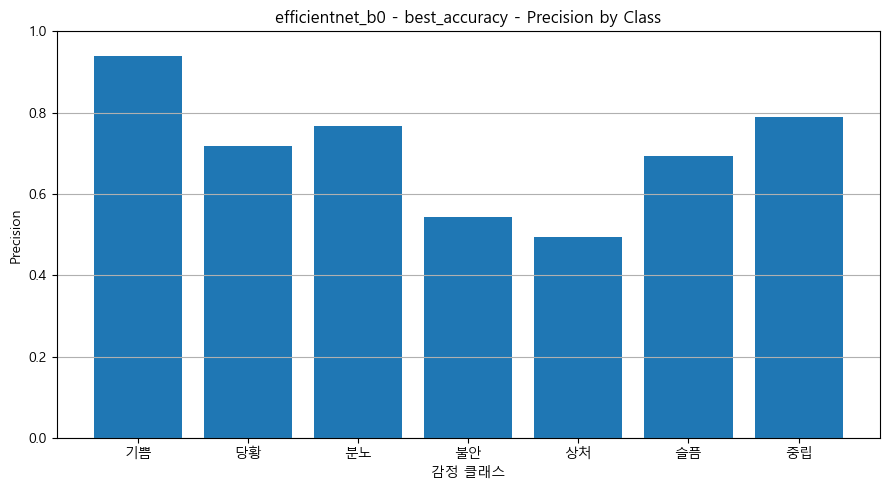

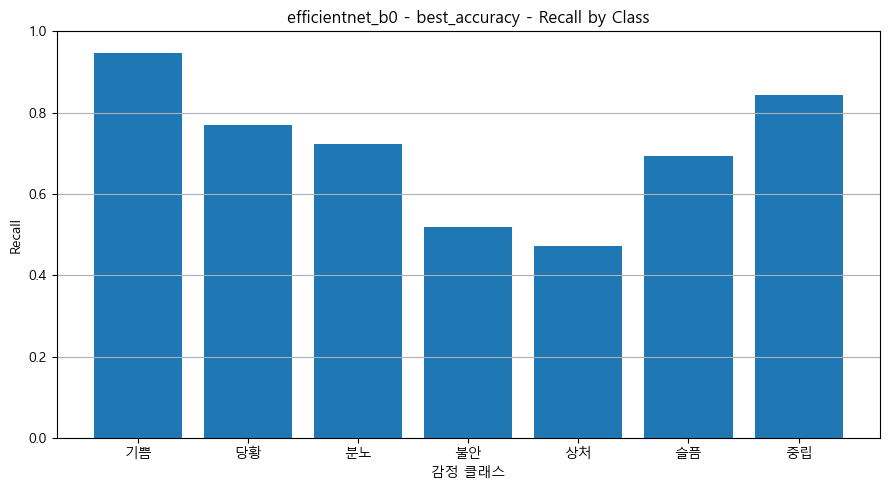

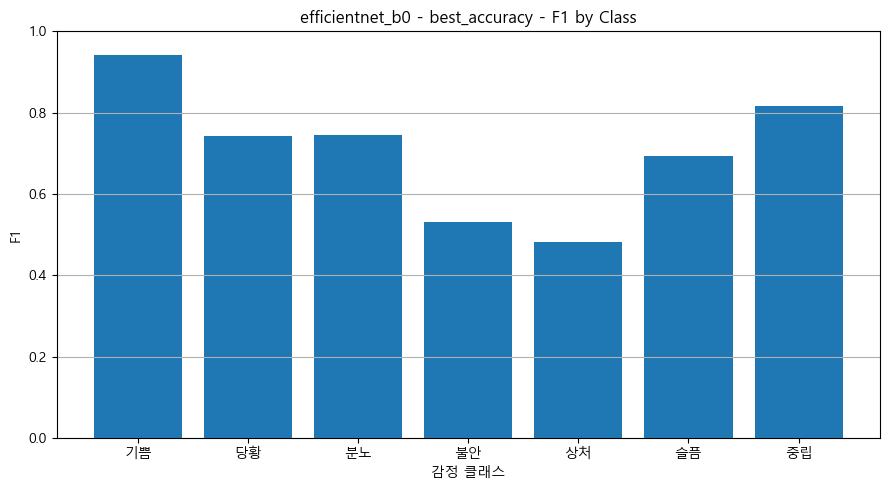

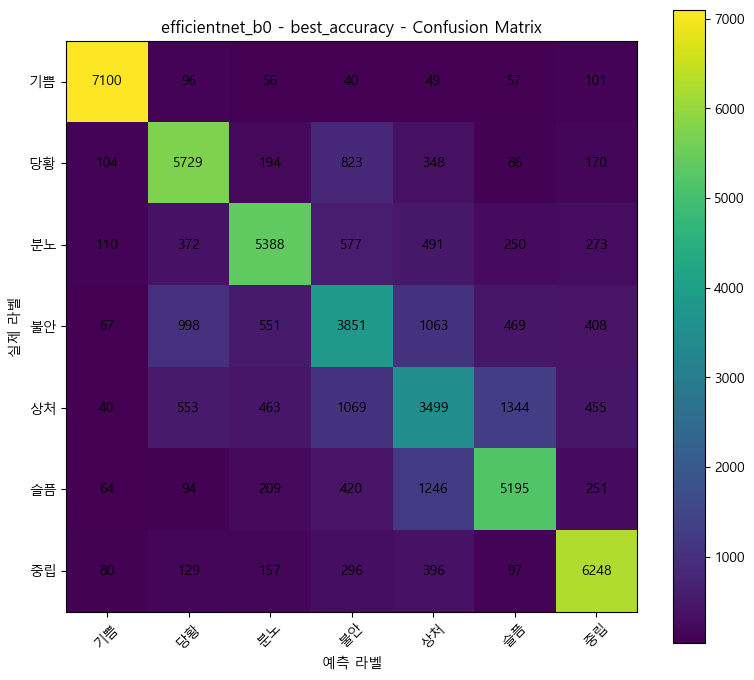

In [19]:
# 4-2. EfficientNetB0
efficientnet_history, efficientnet_best_loss_path, efficientnet_best_accuracy_path = train_model(
    model_name="efficientnet_b0",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

efficientnet_loss_result = evaluate_best_model(
    model_name="efficientnet_b0",
    valid_loader=valid_loader,
    device=device,
    best_model_path=efficientnet_best_loss_path,
    checkpoint_type="best_loss",
)

efficientnet_accuracy_result = evaluate_best_model(
    model_name="efficientnet_b0",
    valid_loader=valid_loader,
    device=device,
    best_model_path=efficientnet_best_accuracy_path,
    checkpoint_type="best_accuracy",
)


### 4-3. ResNet18 본학습

마지막으로 같은 조건에서 ResNet18을 학습한다.


===== resnet18 2차 학습 시작 =====
Epoch 01 | train_loss=1.0711 | train_acc=0.5990 | valid_loss=1.0342 | valid_acc=0.6250 | 909.8s
  -> Best Loss model 저장: resnet18_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: resnet18_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 02 | train_loss=0.8673 | train_acc=0.6774 | valid_loss=0.9507 | valid_acc=0.6507 | 919.7s
  -> Best Loss model 저장: resnet18_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: resnet18_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 03 | train_loss=0.7620 | train_acc=0.7166 | valid_loss=0.9361 | valid_acc=0.6698 | 915.5s
  -> Best Loss model 저장: resnet18_pretrained_v2_repro_institute_seatpc_best_loss.pt
  -> Best Accuracy model 저장: resnet18_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
Epoch 04 | train_loss=0.6728 | train_acc=0.7498 | valid_loss=0.9098 | valid_acc=0.6720 | 912.0s
  -> Best Loss model 저장: resnet18_pretrained_v2_repro_ins

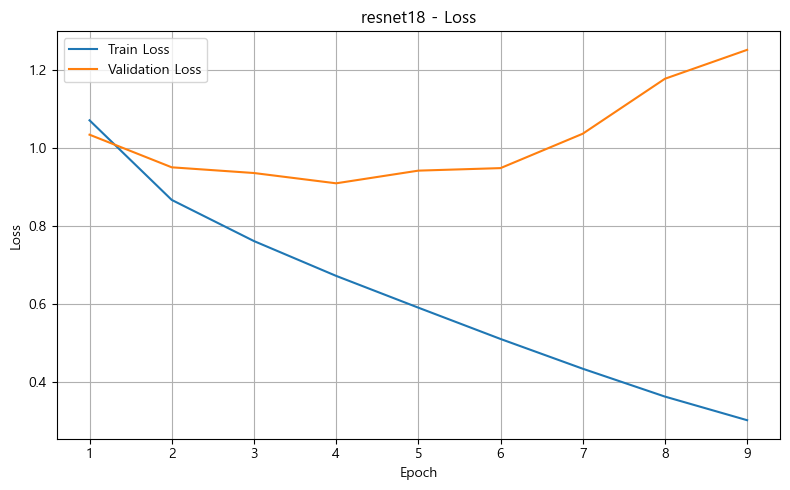

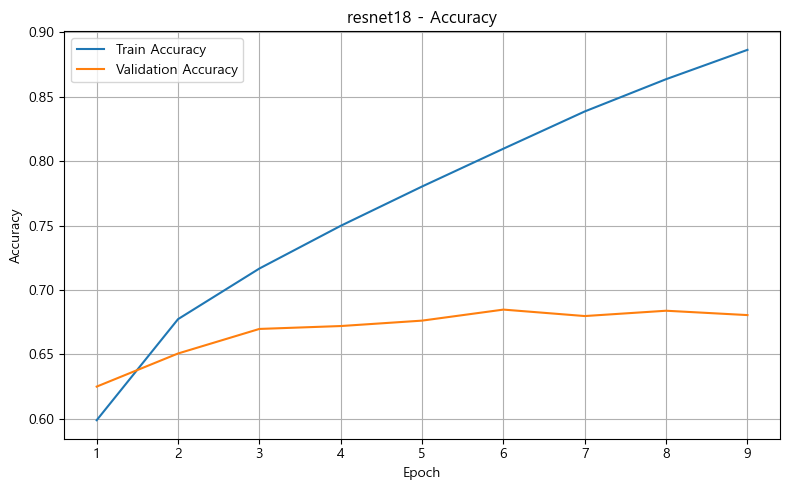

Best Loss model 경로: D:\emotion_recognition_project\05_models\resnet18_pretrained_v2_repro_institute_seatpc_best_loss.pt
Best Accuracy model 경로: D:\emotion_recognition_project\05_models\resnet18_pretrained_v2_repro_institute_seatpc_best_accuracy.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\resnet18_pretrained_v2_repro_institute_seatpc_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_16156\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[resnet18] best_loss Validation 평가
Accuracy: 0.672


,class,precision,recall,f1_score
0,기쁨,0.939041,0.934658,0.936844
1,당황,0.764557,0.607727,0.677181
2,분노,0.641458,0.759416,0.695471
3,불안,0.509203,0.489267,0.499036
4,상처,0.430832,0.396066,0.412718
5,슬픔,0.642268,0.687525,0.664127
6,중립,0.768883,0.826422,0.796615


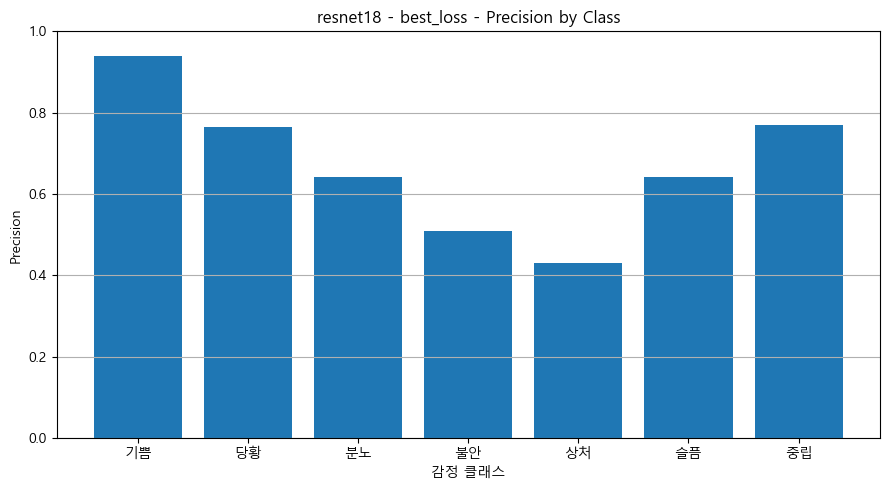

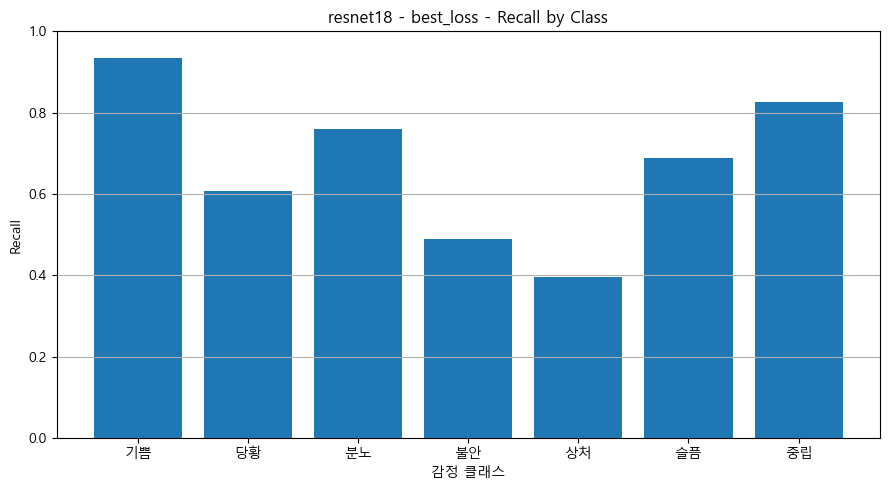

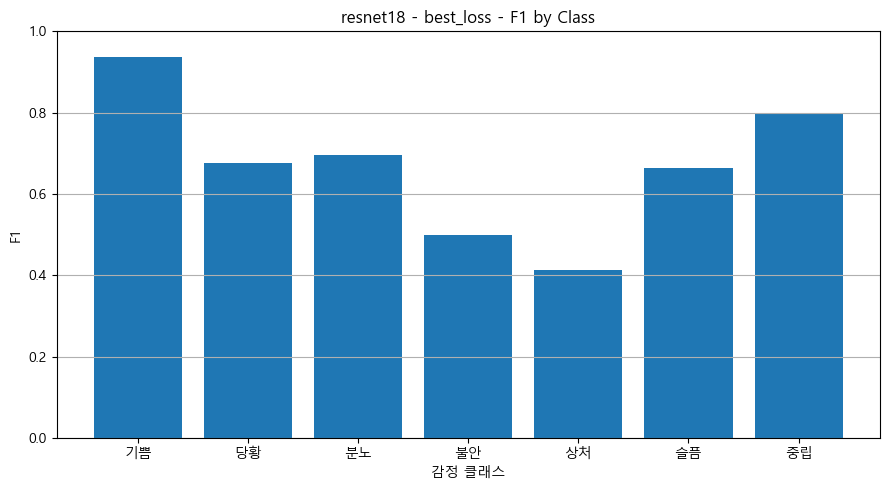

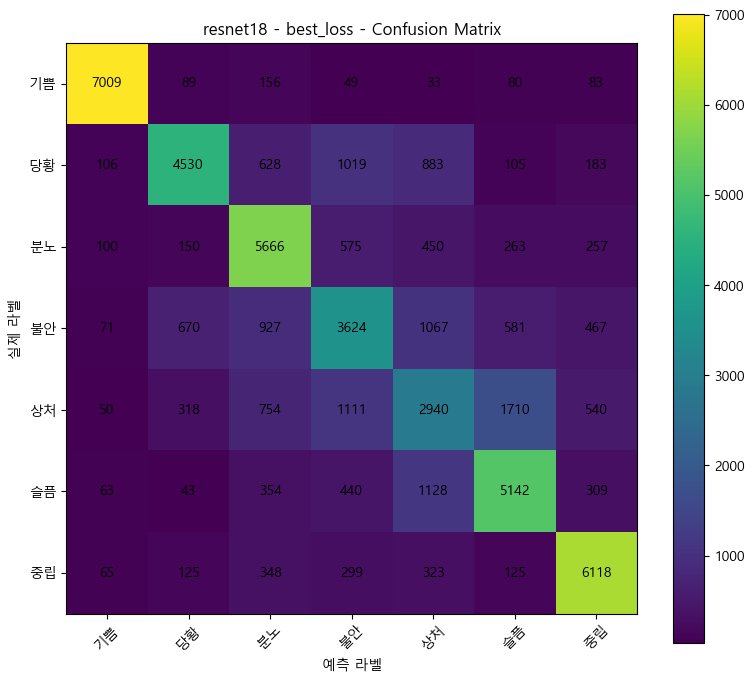

C:\Users\USER\AppData\Local\Temp\ipykernel_16156\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[resnet18] best_accuracy Validation 평가
Accuracy: 0.6848


,class,precision,recall,f1_score
0,기쁨,0.944792,0.926524,0.935569
1,당황,0.736790,0.705259,0.720680
2,분노,0.690598,0.741322,0.715061
3,불안,0.537895,0.453220,0.491940
4,상처,0.457226,0.401051,0.427300
5,슬픔,0.646148,0.691937,0.668259
6,중립,0.727303,0.871133,0.792747


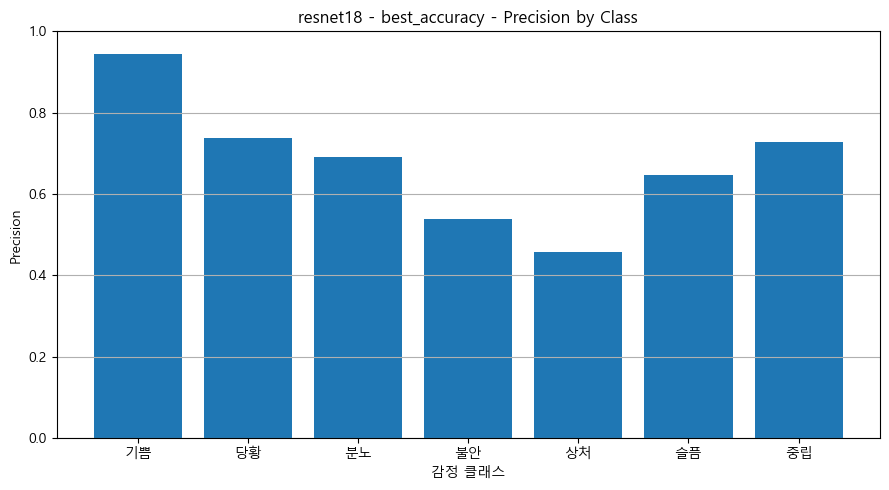

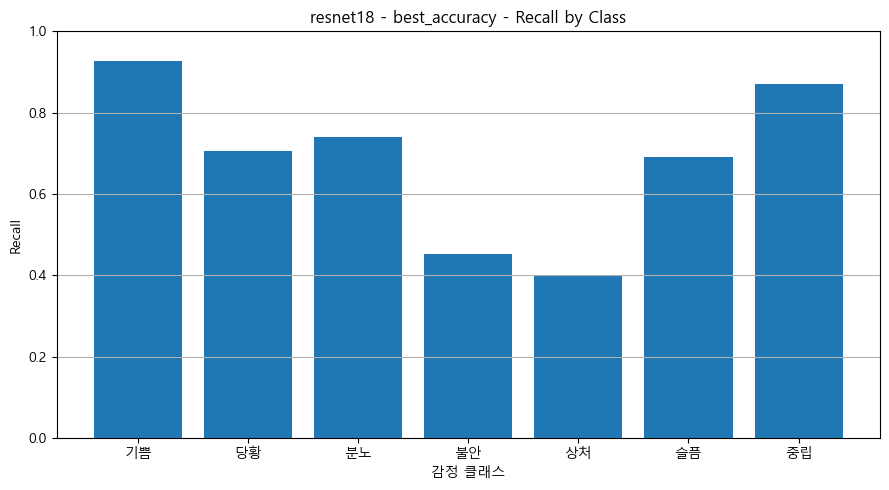

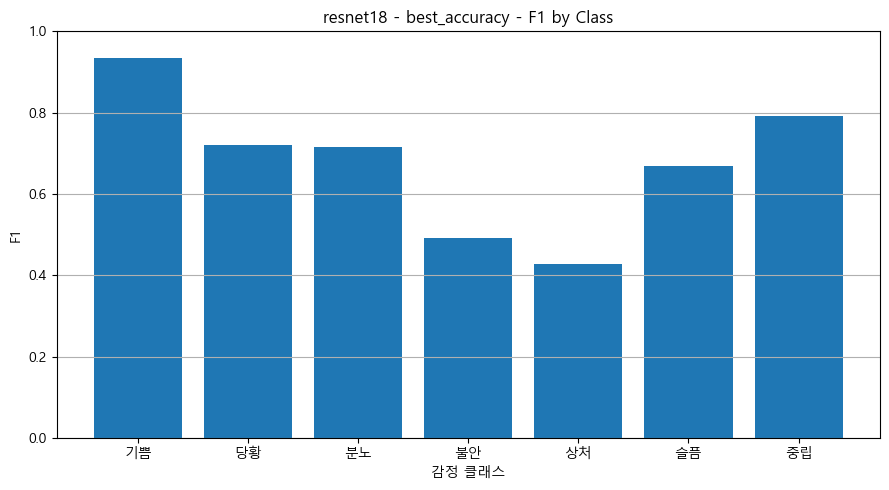

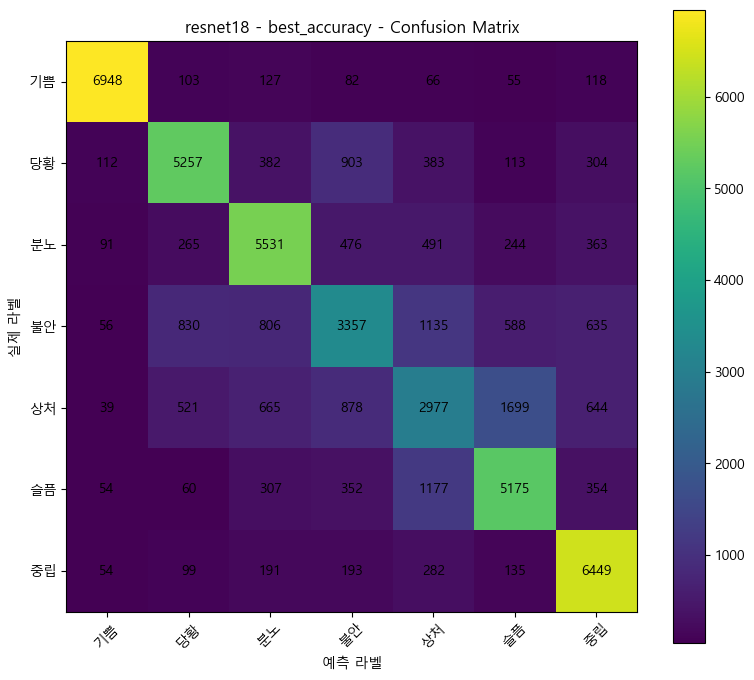

In [20]:
# 4-3. ResNet18
resnet_history, resnet_best_loss_path, resnet_best_accuracy_path = train_model(
    model_name="resnet18",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

resnet_loss_result = evaluate_best_model(
    model_name="resnet18",
    valid_loader=valid_loader,
    device=device,
    best_model_path=resnet_best_loss_path,
    checkpoint_type="best_loss",
)

resnet_accuracy_result = evaluate_best_model(
    model_name="resnet18",
    valid_loader=valid_loader,
    device=device,
    best_model_path=resnet_best_accuracy_path,
    checkpoint_type="best_accuracy",
)


## 5. 세 모델 최종 비교

2차 재현 실험(직능원 내 자리 PC)에서는 세 모델 각각의 두 체크포인트를 비교한다.

- Best Validation Loss
- Best Validation Accuracy

총 6개 체크포인트의 Accuracy / 평균 Precision / 평균 Recall / 평균 F1-score를 비교하고,
각 모델의 학습 중 Best Validation Loss와 Best Validation Accuracy도 별도 표로 저장한다.

,model,checkpoint_type,accuracy,mean_precision,mean_recall,mean_f1
0,mobilenet_v3_small,best_loss,0.626770,0.631231,0.626292,0.622427
1,mobilenet_v3_small,best_accuracy,0.640122,0.640926,0.639761,0.633462
2,efficientnet_b0,best_loss,0.695488,0.693774,0.695057,0.693246
3,efficientnet_b0,best_accuracy,0.710010,0.706535,0.709630,0.707659
4,resnet18,best_loss,0.672006,0.670892,0.671583,0.668856
5,resnet18,best_accuracy,0.684764,0.677250,0.684349,0.678794


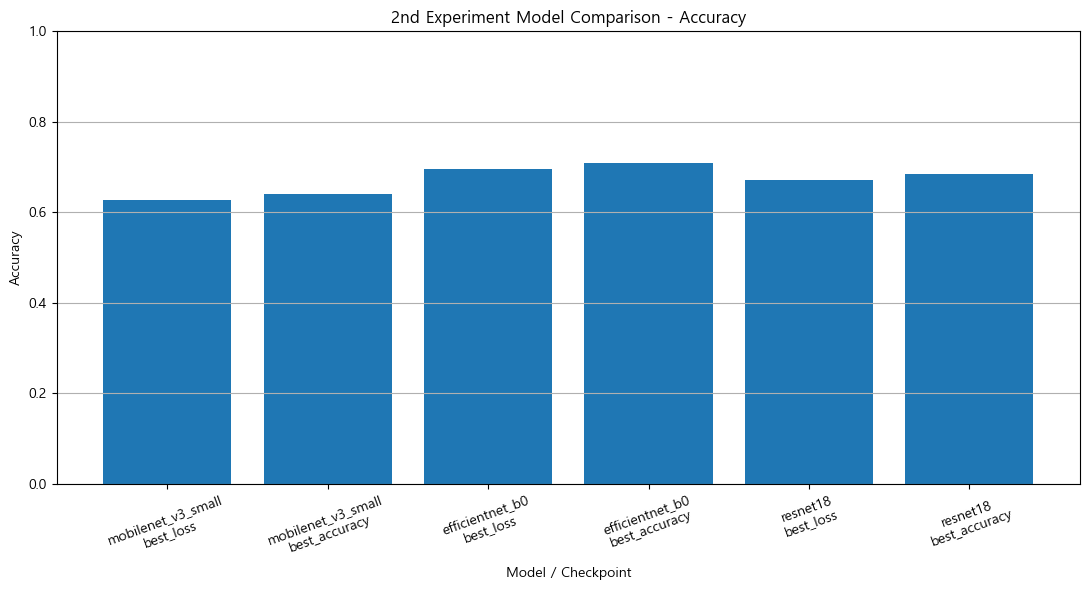

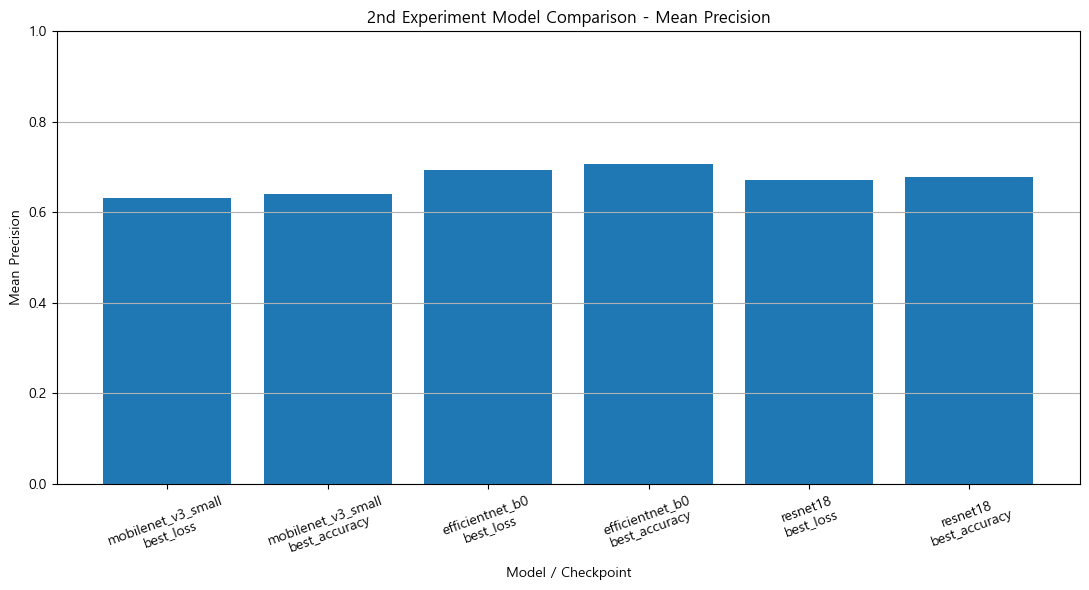

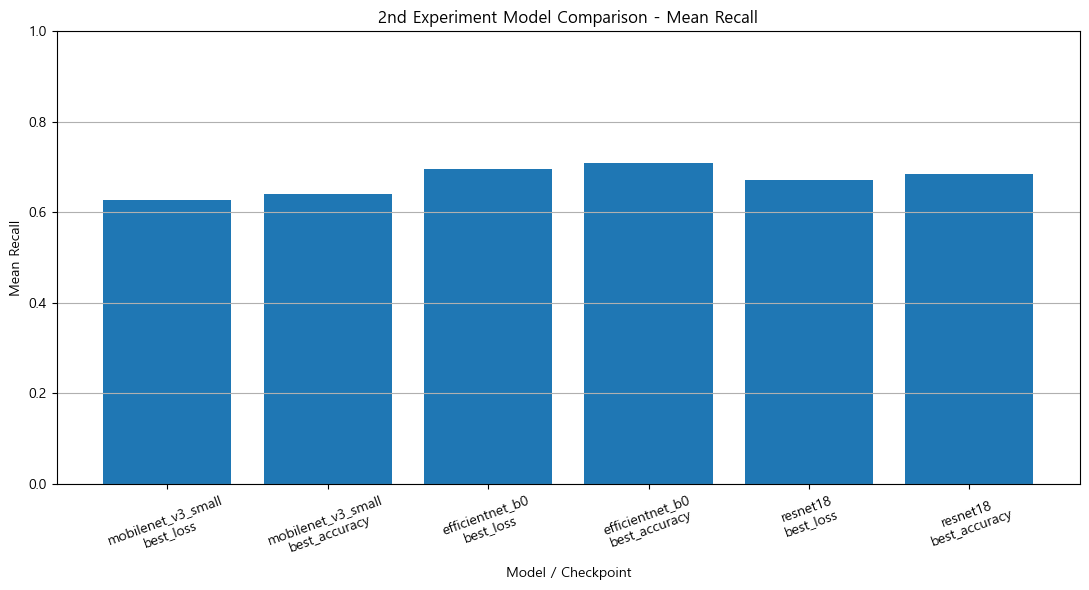

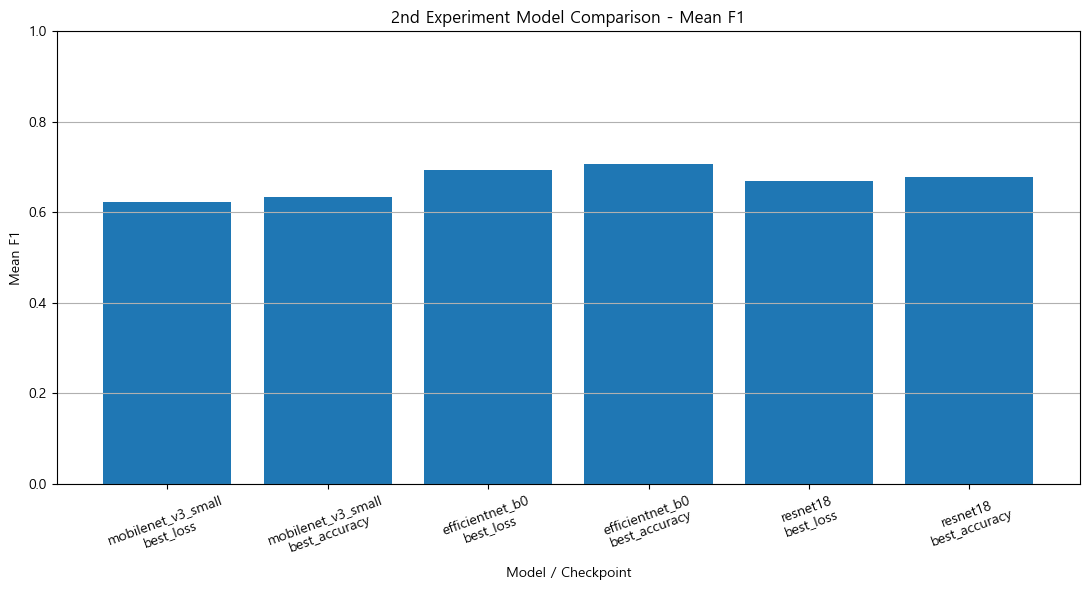

,model,best_valid_loss,best_valid_accuracy
0,mobilenet_v3_small,1.006752,0.640122
1,efficientnet_b0,0.865930,0.710010
2,resnet18,0.909793,0.684764


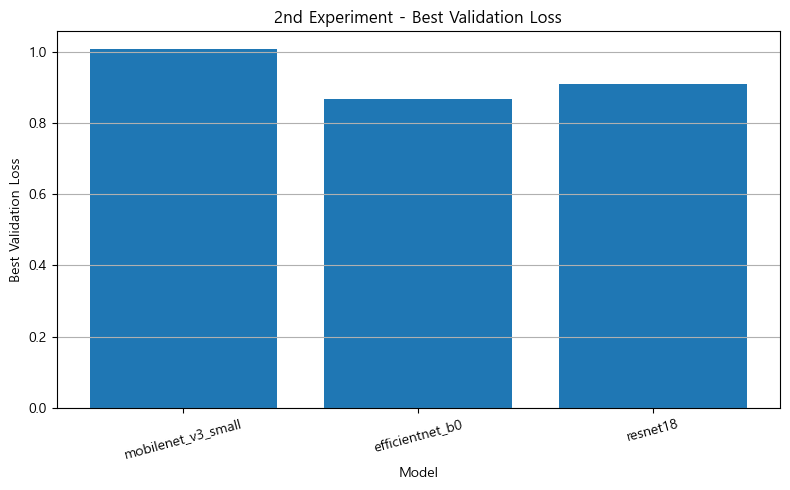

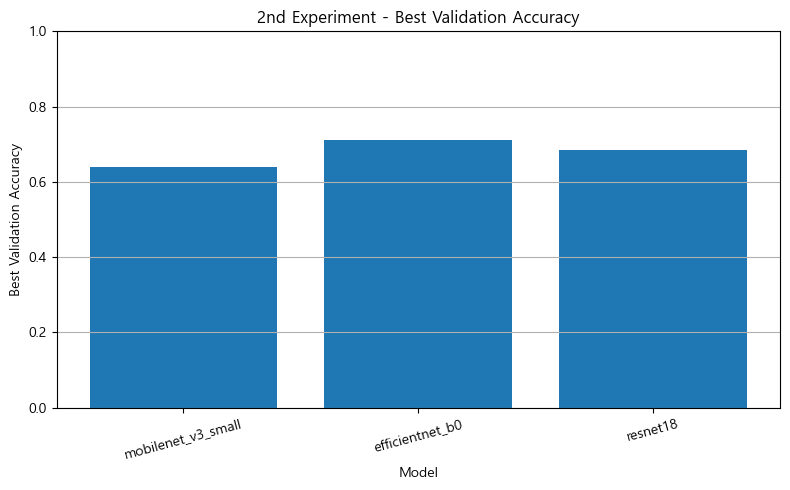


세 모델 2차 학습 및 평가 종료
모델 저장 폴더: D:\emotion_recognition_project\05_models
결과 저장 폴더: D:\emotion_recognition_project\06_outputs
6개 체크포인트 비교 CSV: D:\emotion_recognition_project\06_outputs\pretrained_v2_repro_institute_seatpc_model_comparison_metrics.csv
Best Loss / Accuracy 요약 CSV: D:\emotion_recognition_project\06_outputs\pretrained_v2_repro_institute_seatpc_best_loss_accuracy_summary.csv


In [21]:
# --------------------------------------------------
# 세 모델 × 두 체크포인트 최종 비교
# --------------------------------------------------
model_results = [
    mobilenet_loss_result,
    mobilenet_accuracy_result,
    efficientnet_loss_result,
    efficientnet_accuracy_result,
    resnet_loss_result,
    resnet_accuracy_result,
]

results_df = pd.DataFrame(model_results)

results_path = (
    OUTPUT_DIR
    / f"pretrained_{EXPERIMENT_TAG}_model_comparison_metrics.csv"
)

results_df.to_csv(
    results_path,
    index=False,
    encoding="utf-8-sig",
)

display(results_df)

results_df["display_name"] = (
    results_df["model"]
    + "\n"
    + results_df["checkpoint_type"]
)

comparison_metrics = [
    ("accuracy", "Accuracy"),
    ("mean_precision", "Mean Precision"),
    ("mean_recall", "Mean Recall"),
    ("mean_f1", "Mean F1"),
]

for column, title in comparison_metrics:
    plt.figure(figsize=(11, 6))
    plt.bar(results_df["display_name"], results_df[column])
    plt.ylim(0, 1)
    plt.xlabel("Model / Checkpoint")
    plt.ylabel(title)
    plt.title(f"2nd Experiment Model Comparison - {title}")
    plt.xticks(rotation=20)
    plt.grid(axis="y")
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"pretrained_{EXPERIMENT_TAG}_model_comparison_{column}.png",
        dpi=150,
    )
    plt.show()
    plt.close()


# 각 모델의 학습 과정에서 기록된 최저 Loss / 최고 Accuracy 요약
best_summary_df = pd.DataFrame([
    {
        "model": "mobilenet_v3_small",
        "best_valid_loss": mobilenet_history["valid_loss"].min(),
        "best_valid_accuracy": mobilenet_history["valid_accuracy"].max(),
    },
    {
        "model": "efficientnet_b0",
        "best_valid_loss": efficientnet_history["valid_loss"].min(),
        "best_valid_accuracy": efficientnet_history["valid_accuracy"].max(),
    },
    {
        "model": "resnet18",
        "best_valid_loss": resnet_history["valid_loss"].min(),
        "best_valid_accuracy": resnet_history["valid_accuracy"].max(),
    },
])

best_summary_path = (
    OUTPUT_DIR
    / f"pretrained_{EXPERIMENT_TAG}_best_loss_accuracy_summary.csv"
)

best_summary_df.to_csv(
    best_summary_path,
    index=False,
    encoding="utf-8-sig",
)

display(best_summary_df)


plt.figure(figsize=(8, 5))
plt.bar(best_summary_df["model"], best_summary_df["best_valid_loss"])
plt.xlabel("Model")
plt.ylabel("Best Validation Loss")
plt.title("2nd Experiment - Best Validation Loss")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / f"pretrained_{EXPERIMENT_TAG}_comparison_best_valid_loss.png",
    dpi=150,
)
plt.show()
plt.close()


plt.figure(figsize=(8, 5))
plt.bar(best_summary_df["model"], best_summary_df["best_valid_accuracy"])
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy")
plt.title("2nd Experiment - Best Validation Accuracy")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / f"pretrained_{EXPERIMENT_TAG}_comparison_best_valid_accuracy.png",
    dpi=150,
)
plt.show()
plt.close()

print("\n세 모델 2차 학습 및 평가 종료")
print("모델 저장 폴더:", MODEL_DIR)
print("결과 저장 폴더:", OUTPUT_DIR)
print("6개 체크포인트 비교 CSV:", results_path)
print("Best Loss / Accuracy 요약 CSV:", best_summary_path)

### 발표 때 설명할 핵심

1. **2차 재현 실험(직능원 교실 PC)을 왜 했나?**  
   1차 실험에서는 Validation Loss가 가장 낮은 모델만 저장했다.
   학습 로그를 확인해 보니 Validation Loss 최저 Epoch와 Validation Accuracy 최고 Epoch가
   서로 다를 수 있어, 두 기준의 모델을 모두 보존하여 비교하기 위해 2차 재현 실험(직능원 교실 PC)을 진행했다.

2. **무엇을 바꿨나?**  
   데이터, 모델, Optimizer, Learning Rate, Batch Size, 최대 Epoch,
   EarlyStopping patience 등 학습 조건은 그대로 유지했다.
   바꾼 것은 **Best model 저장 방식**이다.

3. **무엇을 저장하나?**  
   각 모델마다 `best_loss.pt`와 `best_accuracy.pt`를 각각 저장한다.

4. **EarlyStopping 기준은 무엇인가?**  
   1차 실험과 동일하게 Validation Loss 기준이다.
   Validation Loss가 5 Epoch 연속 개선되지 않으면 종료한다.

5. **최종 비교는 어떻게 하나?**  
   총 6개 체크포인트를 같은 Validation set에서
   Accuracy / Precision / Recall / F1-score / Confusion Matrix로 비교한다.

6. **기존 결과는 어떻게 처리했나?**  
   1차 실험 결과는 그대로 보존하고,
   2차 재현 실험(직능원 내 자리 PC)의 모든 파일명에 `v2_dual_best`를 붙여 덮어쓰기를 방지했다.

7. **왜 'Validation 평가 결과'라고 표현하나?**  
   별도의 독립 Test set 없이 Validation set을 모델 선택과 평가에 사용했기 때문에
   발표에서는 **Best model의 Validation 평가 결과**라고 표현한다.